In [2]:
import torch 
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt 
import random

In [2]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307), (0.3081))])

MNIST_tr = datasets.MNIST(root = "MNIST", train = True, transform = transform, download = True)
MNIST_ts = datasets.MNIST(root = "MNIST",train = False, transform = transform, download = True)

In [3]:
tr_loader = DataLoader(MNIST_tr,batch_size= 64, shuffle = True, drop_last = True)
ts_loader = DataLoader(MNIST_ts,batch_size= 64, shuffle = False, drop_last = True)

In [ ]:
torch.manual_seed(2009)

class MNIST(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels= 8, kernel_size= 3, padding= 1), #28 x 28
            nn.ReLU(),
            nn.Conv2d(in_channels=8, out_channels= 16, kernel_size= 3, padding= 0), #26 x 26
            #nn.BatchNorm2d(num_features= 16),
            nn.Conv2d(in_channels=16,out_channels=24, kernel_size= 3), #24 x 24
            nn.ReLU(),
            nn.MaxPool2d(kernel_size= 2), #12 x 12
            nn.Conv2d(in_channels=24,out_channels=30, kernel_size= 3), #10 x 10
           # nn.BatchNorm2d(num_features= 30),
            nn.ReLU(),
            nn.Conv2d(in_channels=30,out_channels=32, kernel_size= 3),
            nn.ReLU(),
          #  nn.Dropout(p = 0.2),
            nn.AdaptiveAvgPool2d(output_size= (1,1))
        )

        self.linear_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32,10)
        )

    def forward(self,x):
        x = self.conv_layers(x)
        x = self.linear_layers(x)
        return x
    
    def acc_classify(self,x):
        self.eval()
        with torch.inference_mode():
            x = self.forward(x)
            x = torch.softmax(x, dim = 1)
            x = torch.argmax(x,dim = 1)
        return x

In [5]:
model = MNIST().to("cuda")

In [6]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model.parameters(), lr = 3e-4)
epoch_num = 10

In [7]:
model.load_state_dict(torch.load("MNIST.pth", weights_only= True))

<All keys matched successfully>

In [ ]:
for epoch in range(epoch_num):
    num_r = 0 
    for batch_num, (X,y) in enumerate(tr_loader):
        model.train()
        X = X.to("cuda")
        y = y.to("cuda")
        log = model(X)
        loss = loss_fn(log,y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        num_r += (model.acc_classify(X) == y).sum().item()
    
    print(f"Epoch Number {epoch} Accuracy : {num_r / ((batch_num + 1) * 64)}")

In [59]:
def tr_acc(model):
        num_r = 0
        for batch_num, (X,y) in enumerate(tr_loader):
                X = X.to("cuda")
                y = y.to("cuda")
                num_r += (model.acc_classify(X) == y).sum().item()
        return num_r / ((batch_num + 1) * 64)

In [60]:
def ts_acc(model):
        num_r = 0
        for batch_num, (X,y) in enumerate(ts_loader):
                X = X.to("cuda")
                y = y.to("cuda")
                num_r += (model.acc_classify(X) == y).sum().item()
        return num_r / ((batch_num + 1) * 64)

In [61]:
tr_acc(model)

0.9556263340448239

In [71]:
ts_acc(model)

0.9587339743589743

In [188]:
transforms.Normalize((0.1307),(0.3081))(MNIST_ts.data[item].unsqueeze(0).float() / 255).shape

torch.Size([1, 28, 28])

In [189]:
model.acc_classify(transforms.Normalize((0.1307),(0.3081))(MNIST_ts.data[item].unsqueeze(0).float() / 255).to("cuda"))

tensor([8], device='cuda:0')

In [212]:
import time

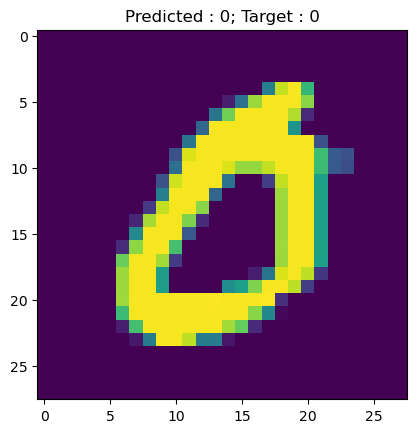

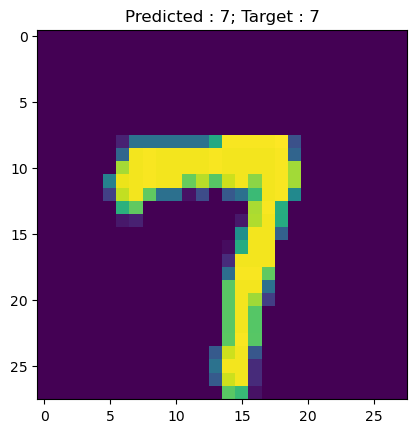

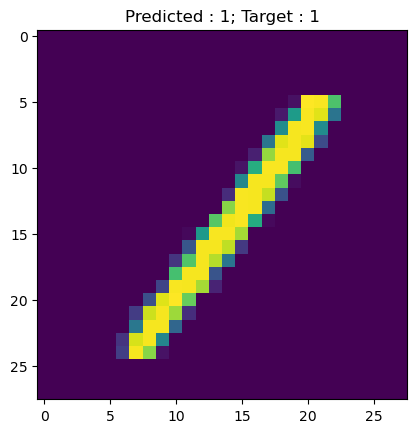

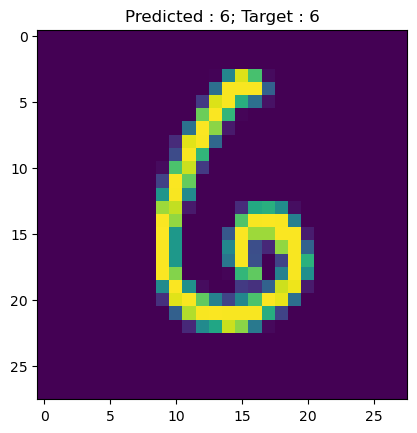

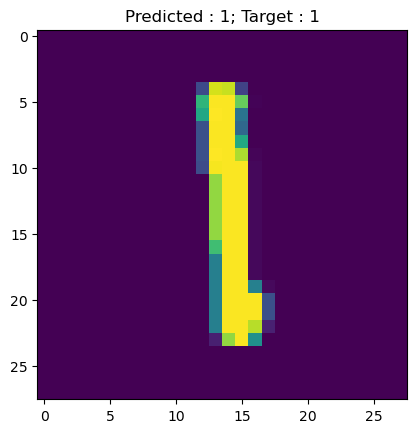

KeyboardInterrupt: 

Exception ignored in: 'zmq.backend.cython.message.Frame.__dealloc__'
Traceback (most recent call last):
  File "zmq\\backend\\cython\\checkrc.pxd", line 13, in zmq.backend.cython.checkrc._check_rc
KeyboardInterrupt: 


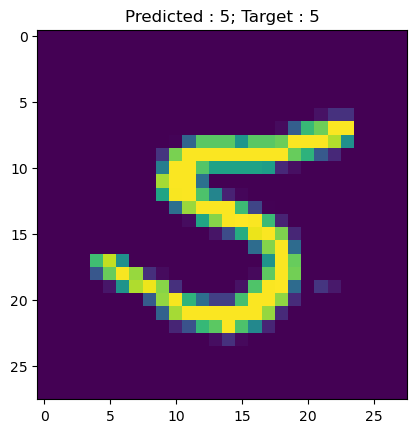

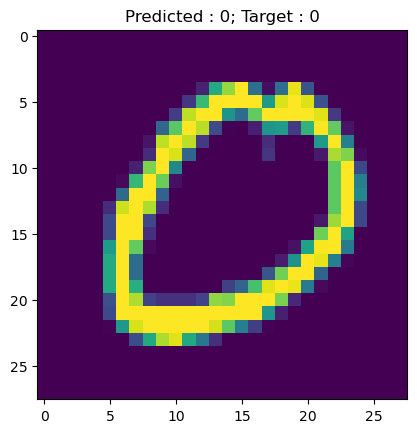

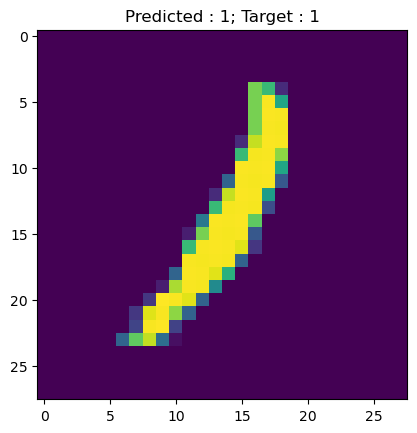

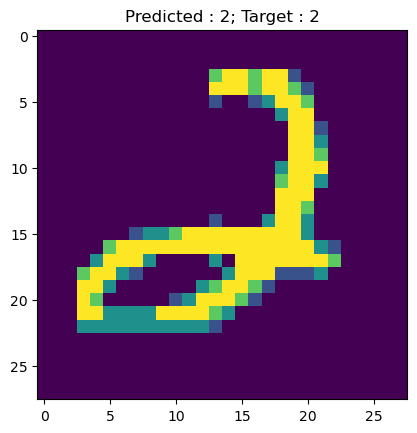

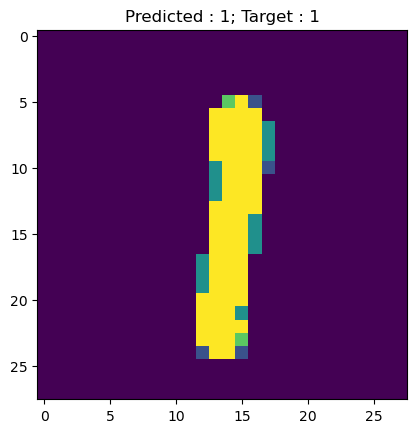

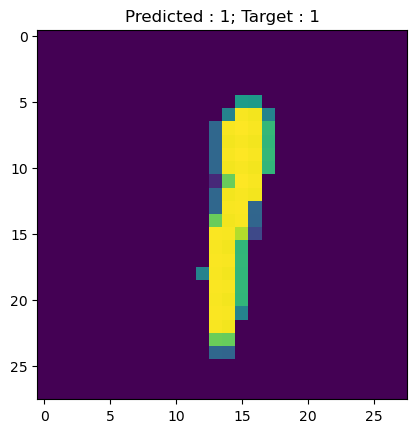

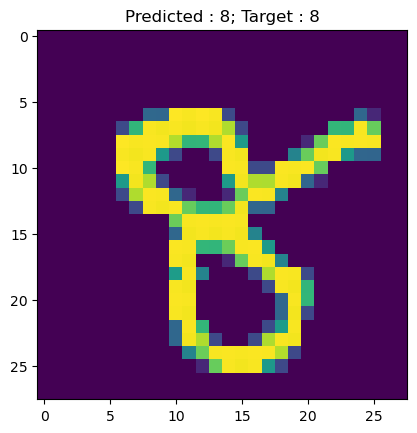

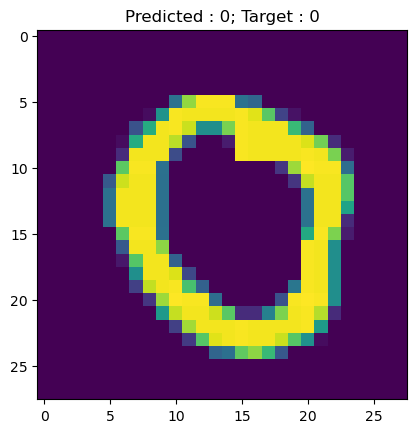

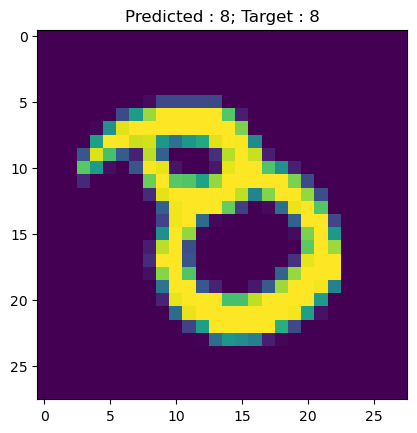

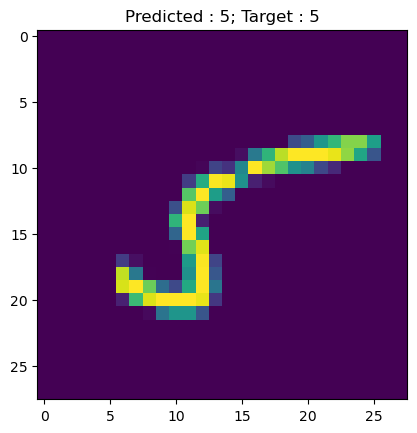

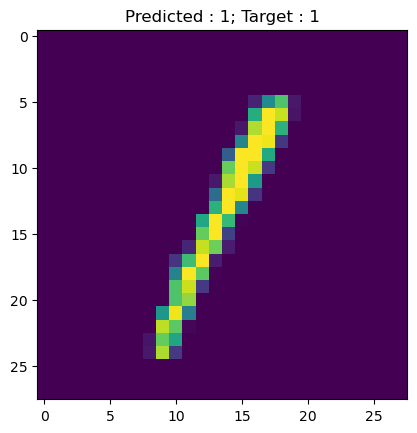

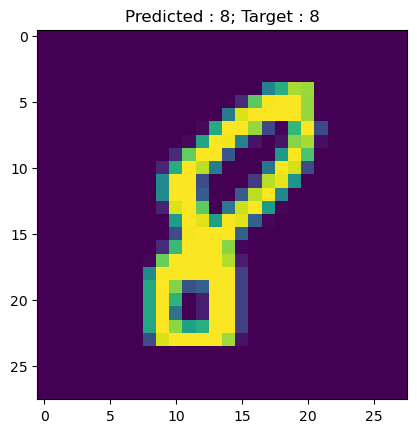

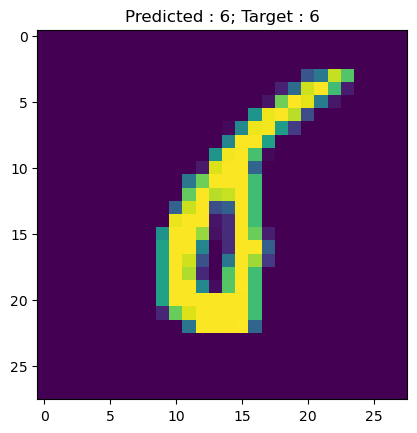

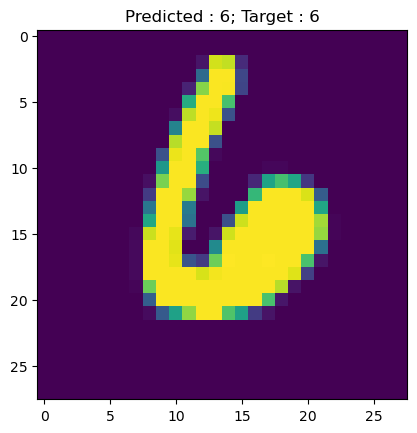

In [ ]:
for i in range(100):
    while True:
        item = random.randint(0,len(MNIST_ts.targets) - 1)
        if model.acc_classify(transforms.Normalize((0.1307),(0.3081))(MNIST_ts.data[item].unsqueeze(0).float() / 255).to("cuda")).item() == MNIST_ts.targets[item].item():
            break
    plt.clf()
    plt.imshow(MNIST_ts.data[item].squeeze().to("cpu"))
    plt.title(f"Predicted : {model.acc_classify(transforms.Normalize((0.1307),(0.3081))(MNIST_ts.data[item].unsqueeze(0).float() / 255).to("cuda")).item()}; Target : {MNIST_ts.targets[item].item()}")
    plt.show()
    time.sleep(1)

In [69]:
torch.save(model.state_dict(),"MNIST.pth")